In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)

print("Digital Twin environment ready!")

Matplotlib is building the font cache; this may take a moment.


Digital Twin environment ready!


In [2]:
# Step 2: Generate synthetic manufacturing process data

n_samples = 1000

temperature = np.random.normal(450, 25, n_samples)      # °C
pressure = np.random.normal(5.0, 0.6, n_samples)        # bar
machine_speed = np.random.normal(120, 15, n_samples)    # units/min
material_ratio = np.random.uniform(0.2, 0.8, n_samples)

# Simulated energy consumption
energy_consumption = (
    0.04 * temperature
    + 1.8 * pressure
    + 0.06 * machine_speed
    + 8 * material_ratio
    + np.random.normal(0, 1.5, n_samples)
)

# Simulated product quality score
quality_score = (
    95
    - 0.002 * (temperature - 450)**2
    - 0.8 * (pressure - 5)**2
    - 0.003 * (machine_speed - 120)**2
    - 8 * (material_ratio - 0.5)**2
    + np.random.normal(0, 1, n_samples)
)

df = pd.DataFrame({
    "temperature_C": temperature,
    "pressure_bar": pressure,
    "machine_speed": machine_speed,
    "material_ratio": material_ratio,
    "energy_consumption": energy_consumption,
    "quality_score": quality_score
})

print("Dataset created successfully!")
print("Shape:", df.shape)

df.head()

Dataset created successfully!
Shape: (1000, 6)


,temperature_C,pressure_bar,machine_speed,material_ratio,energy_consumption,quality_score
0,462.417854,5.839613,109.872326,0.691244,41.401905,91.437027
1,446.543392,5.554780,117.832220,0.790140,43.206313,93.872072
2,466.192213,5.035778,108.113701,0.355803,37.924580,93.618800
3,488.075746,4.611838,115.380577,0.781834,40.383225,90.880600
4,444.146166,5.418934,91.595780,0.458740,37.071396,92.242402


In [3]:
# Step 3: Save the synthetic manufacturing dataset

df.to_csv("../data/manufacturing_process_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


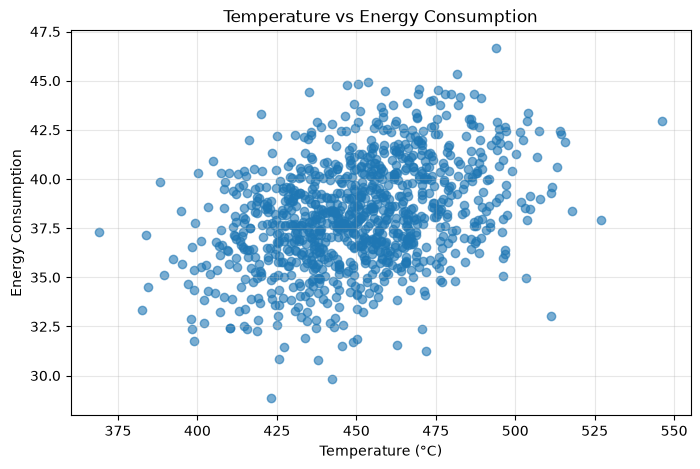

In [4]:
# Step 4: Visualize the manufacturing process

plt.figure(figsize=(8, 5))

plt.scatter(
    df["temperature_C"],
    df["energy_consumption"],
    alpha=0.6
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Energy Consumption")
plt.title("Temperature vs Energy Consumption")
plt.grid(alpha=0.3)

plt.show()

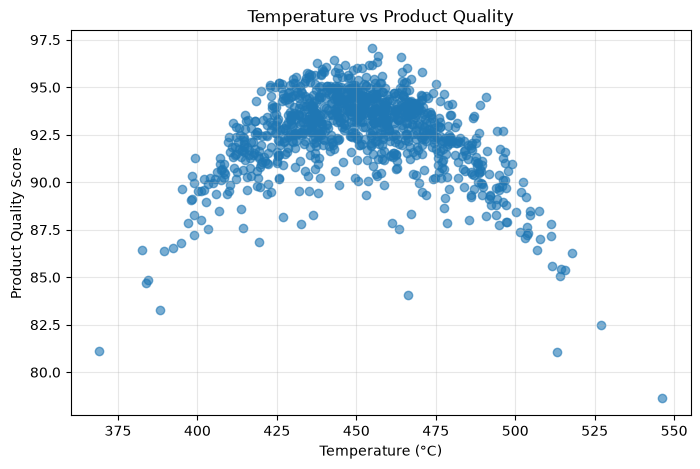

In [5]:
# Step 5: Visualize process temperature vs product quality

plt.figure(figsize=(8, 5))

plt.scatter(
    df["temperature_C"],
    df["quality_score"],
    alpha=0.6
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Product Quality Score")
plt.title("Temperature vs Product Quality")
plt.grid(alpha=0.3)

plt.show()

In [6]:
# Step 6: Prepare data for AI-based quality prediction

features = [
    "temperature_C",
    "pressure_bar",
    "machine_speed",
    "material_ratio"
]

X = df[features]
y = df["quality_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features:", features)

Training samples: 800
Testing samples: 200
Features: ['temperature_C', 'pressure_bar', 'machine_speed', 'material_ratio']


In [7]:
# Step 7: Train the Digital Twin quality prediction model

quality_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

quality_model.fit(X_train, y_train)

y_pred = quality_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model training completed!")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"R² Score: {r2:.3f}")

Model training completed!
Mean Absolute Error (MAE): 0.889
R² Score: 0.689


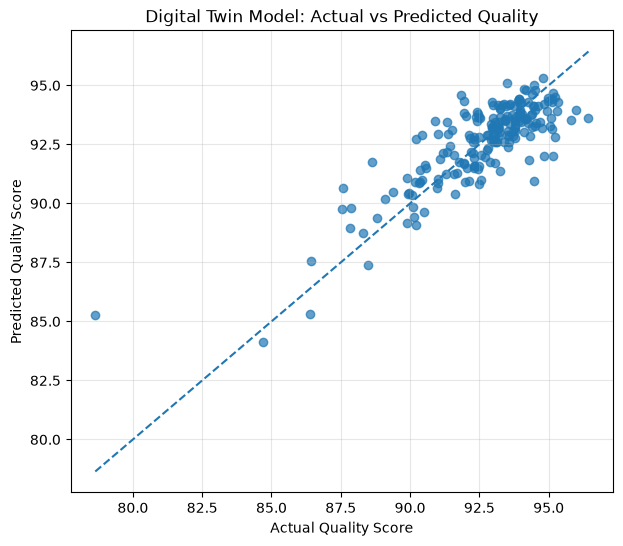

In [8]:
# Step 8: Compare actual and predicted product quality

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Quality Score")
plt.ylabel("Predicted Quality Score")
plt.title("Digital Twin Model: Actual vs Predicted Quality")
plt.grid(alpha=0.3)

plt.show()

          Feature  Importance
0   temperature_C    0.629123
2   machine_speed    0.220622
1    pressure_bar    0.079537
3  material_ratio    0.070718


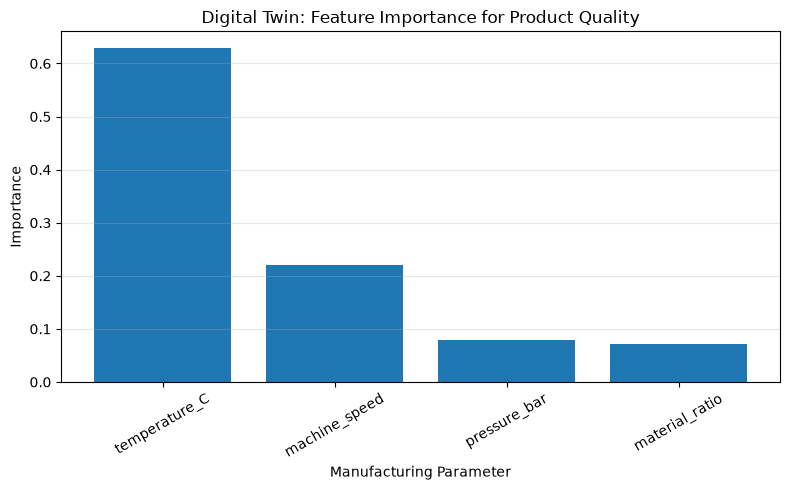

In [9]:
# Step 9: Analyze feature importance

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": quality_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(8, 5))
plt.bar(importance_df["Feature"], importance_df["Importance"])

plt.xlabel("Manufacturing Parameter")
plt.ylabel("Importance")
plt.title("Digital Twin: Feature Importance for Product Quality")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Step 10: Search for optimal manufacturing settings

n_candidates = 5000

candidates = pd.DataFrame({
    "temperature_C": np.random.uniform(400, 500, n_candidates),
    "pressure_bar": np.random.uniform(4, 6, n_candidates),
    "machine_speed": np.random.uniform(80, 120, n_candidates),
    "material_ratio": np.random.uniform(0.3, 0.8, n_candidates)
})

# Predict product quality for each candidate setting
candidates["predicted_quality"] = quality_model.predict(
    candidates[features]
)

# Find the setting with the highest predicted quality
best_setting = candidates.loc[
    candidates["predicted_quality"].idxmax()
]

print("Optimal manufacturing settings:")
print(best_setting)

Optimal manufacturing settings:
temperature_C        456.161616
pressure_bar           4.870795
machine_speed        116.729122
material_ratio         0.562213
predicted_quality     95.343593
Name: 4437, dtype: float64


In [11]:
# Step 11: Train an energy consumption prediction model

X_energy = df[features]
y_energy = df["energy_consumption"]

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_energy,
    y_energy,
    test_size=0.20,
    random_state=42
)

energy_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

energy_model.fit(X_train_e, y_train_e)

energy_pred = energy_model.predict(X_test_e)

energy_mae = mean_absolute_error(y_test_e, energy_pred)
energy_r2 = r2_score(y_test_e, energy_pred)

print("Energy prediction model trained!")
print(f"Energy MAE: {energy_mae:.3f}")
print(f"Energy R² Score: {energy_r2:.3f}")

Energy prediction model trained!
Energy MAE: 1.293
Energy R² Score: 0.652


In [12]:
# Step 12: Multi-objective optimization
# Goal: maximize product quality while minimizing energy consumption

optimization_candidates = candidates.copy()

# Predict energy consumption
optimization_candidates["predicted_energy"] = energy_model.predict(
    optimization_candidates[features]
)

# Normalize predicted quality and energy
quality_norm = (
    optimization_candidates["predicted_quality"]
    - optimization_candidates["predicted_quality"].min()
) / (
    optimization_candidates["predicted_quality"].max()
    - optimization_candidates["predicted_quality"].min()
)

energy_norm = (
    optimization_candidates["predicted_energy"]
    - optimization_candidates["predicted_energy"].min()
) / (
    optimization_candidates["predicted_energy"].max()
    - optimization_candidates["predicted_energy"].min()
)

# Combined objective:
# Higher quality is better, lower energy is better
optimization_candidates["optimization_score"] = (
    0.7 * quality_norm - 0.3 * energy_norm
)

best_balanced = optimization_candidates.loc[
    optimization_candidates["optimization_score"].idxmax()
]

print("Best quality-energy trade-off:")
print(best_balanced)

Best quality-energy trade-off:
temperature_C         439.137809
pressure_bar            4.227303
machine_speed         115.359702
material_ratio          0.318481
predicted_quality      95.159472
predicted_energy       34.736378
optimization_score      0.596180
Name: 2805, dtype: float64


In [13]:
# Step 13: Compare quality-only and balanced optimization

quality_only = optimization_candidates.loc[
    optimization_candidates["predicted_quality"].idxmax()
]

comparison = pd.DataFrame({
    "Quality-only optimization": [
        quality_only["predicted_quality"],
        quality_only["predicted_energy"]
    ],
    "Quality-energy optimization": [
        best_balanced["predicted_quality"],
        best_balanced["predicted_energy"]
    ]
}, index=[
    "Predicted Quality",
    "Predicted Energy Consumption"
])

print("Optimization comparison:")
print(comparison)

quality_loss = (
    quality_only["predicted_quality"]
    - best_balanced["predicted_quality"]
)

energy_saving = (
    quality_only["predicted_energy"]
    - best_balanced["predicted_energy"]
)

energy_saving_percent = (
    energy_saving / quality_only["predicted_energy"] * 100
)

print()
print(f"Quality reduction: {quality_loss:.3f} points")
print(f"Energy saving: {energy_saving:.3f} units")
print(f"Energy saving percentage: {energy_saving_percent:.2f}%")

Optimization comparison:
                              Quality-only optimization  \
Predicted Quality                             95.343593   
Predicted Energy Consumption                  38.049599   

                              Quality-energy optimization  
Predicted Quality                               95.159472  
Predicted Energy Consumption                    34.736378  

Quality reduction: 0.184 points
Energy saving: 3.313 units
Energy saving percentage: 8.71%


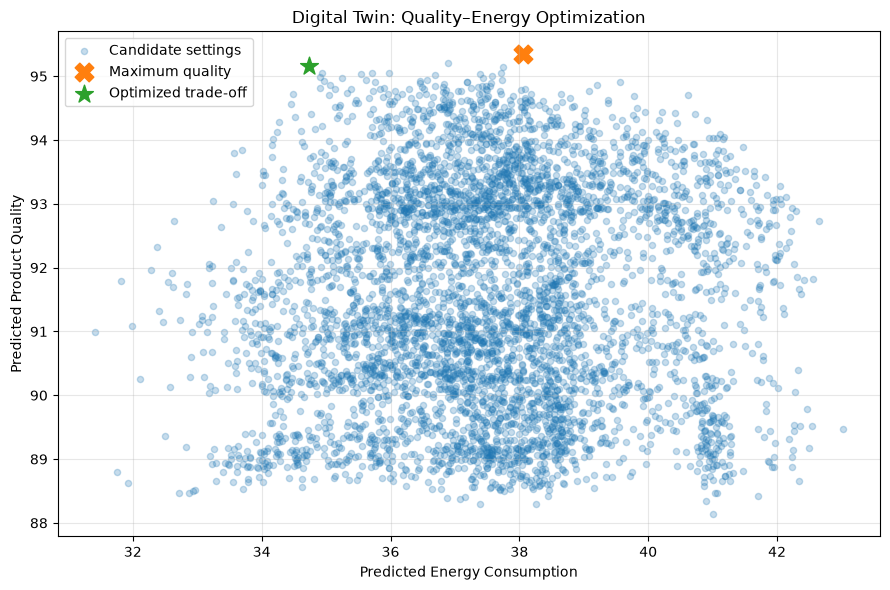

In [14]:
# Step 14: Visualize the quality-energy optimization trade-off

plt.figure(figsize=(9, 6))

plt.scatter(
    optimization_candidates["predicted_energy"],
    optimization_candidates["predicted_quality"],
    alpha=0.25,
    s=20,
    label="Candidate settings"
)

plt.scatter(
    quality_only["predicted_energy"],
    quality_only["predicted_quality"],
    s=180,
    marker="X",
    label="Maximum quality"
)

plt.scatter(
    best_balanced["predicted_energy"],
    best_balanced["predicted_quality"],
    s=180,
    marker="*",
    label="Optimized trade-off"
)

plt.xlabel("Predicted Energy Consumption")
plt.ylabel("Predicted Product Quality")
plt.title("Digital Twin: Quality–Energy Optimization")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../figures/quality_energy_optimization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# Step 15: Save the optimized Digital Twin operating settings

optimal_result = pd.DataFrame({
    "Parameter": [
        "Temperature (C)",
        "Pressure (bar)",
        "Machine Speed",
        "Material Ratio",
        "Predicted Quality",
        "Predicted Energy Consumption"
    ],
    "Optimized Value": [
        best_balanced["temperature_C"],
        best_balanced["pressure_bar"],
        best_balanced["machine_speed"],
        best_balanced["material_ratio"],
        best_balanced["predicted_quality"],
        best_balanced["predicted_energy"]
    ]
})

optimal_result.to_csv(
    "../data/optimized_manufacturing_settings.csv",
    index=False
)

print("Optimized Digital Twin settings saved successfully!")
optimal_result

Optimized Digital Twin settings saved successfully!


,Parameter,Optimized Value
0,Temperature (C),439.137809
1,Pressure (bar),4.227303
2,Machine Speed,115.359702
3,Material Ratio,0.318481
4,Predicted Quality,95.159472
5,Predicted Energy Consumption,34.736378


In [16]:
# Step 16: Simulate real-time Digital Twin monitoring

# Simulated real-time sensor data
real_time_data = pd.DataFrame({
    "temperature_C": [440.0],
    "pressure_bar": [4.25],
    "machine_speed": [115.0],
    "material_ratio": [0.32]
})

# Predict product quality
real_time_quality = quality_model.predict(
    real_time_data[features]
)[0]

# Predict energy consumption
real_time_energy = energy_model.predict(
    real_time_data[features]
)[0]

print("=== Real-Time Digital Twin Monitoring ===")
print(f"Temperature: {real_time_data['temperature_C'].iloc[0]:.2f} °C")
print(f"Pressure: {real_time_data['pressure_bar'].iloc[0]:.2f} bar")
print(f"Machine Speed: {real_time_data['machine_speed'].iloc[0]:.2f}")
print(f"Material Ratio: {real_time_data['material_ratio'].iloc[0]:.3f}")

print()
print(f"Predicted Product Quality: {real_time_quality:.3f}")
print(f"Predicted Energy Consumption: {real_time_energy:.3f}")

# Compare current operation with optimized Digital Twin settings
quality_difference = (
    best_balanced["predicted_quality"] - real_time_quality
)

energy_difference = (
    real_time_energy - best_balanced["predicted_energy"]
)

print()
print("=== Comparison with Optimized Digital Twin ===")
print(f"Quality difference: {quality_difference:.3f}")
print(f"Extra energy consumption: {energy_difference:.3f}")

=== Real-Time Digital Twin Monitoring ===
Temperature: 440.00 °C
Pressure: 4.25 bar
Machine Speed: 115.00
Material Ratio: 0.320

Predicted Product Quality: 95.108
Predicted Energy Consumption: 35.045

=== Comparison with Optimized Digital Twin ===
Quality difference: 0.051
Extra energy consumption: 0.308


In [17]:
# Step 17: Intelligent Decision Support and Alert System

# Define acceptable operating thresholds
quality_threshold = 94.5
energy_threshold = 35.0

print("=== Digital Twin Decision Support System ===")

# Current predicted operating condition
print(f"Current predicted quality: {real_time_quality:.3f}")
print(f"Current predicted energy: {real_time_energy:.3f}")

print("\n=== System Status ===")

# Quality monitoring
if real_time_quality < quality_threshold:
    print("WARNING: Product quality is below the acceptable threshold.")
    quality_alert = True
else:
    print("Quality status: GOOD")
    quality_alert = False

# Energy monitoring
if real_time_energy > energy_threshold:
    print("WARNING: Energy consumption is above the desired threshold.")
    energy_alert = True
else:
    print("Energy status: GOOD")
    energy_alert = False

print("\n=== Digital Twin Recommendation ===")

# Decision-support logic
if quality_alert or energy_alert:

    print("Adjustment recommended.")
    print("Suggested optimized operating parameters:")

    print(
        f"Temperature: "
        f"{real_time_data['temperature_C'].iloc[0]:.2f}"
        f" -> {best_balanced['temperature_C']:.2f} °C"
    )

    print(
        f"Pressure: "
        f"{real_time_data['pressure_bar'].iloc[0]:.2f}"
        f" -> {best_balanced['pressure_bar']:.2f} bar"
    )

    print(
        f"Machine Speed: "
        f"{real_time_data['machine_speed'].iloc[0]:.2f}"
        f" -> {best_balanced['machine_speed']:.2f}"
    )

    print(
        f"Material Ratio: "
        f"{real_time_data['material_ratio'].iloc[0]:.3f}"
        f" -> {best_balanced['material_ratio']:.3f}"
    )

    print("\nExpected performance after adjustment:")
    print(
        f"Predicted Quality: "
        f"{best_balanced['predicted_quality']:.3f}"
    )
    print(
        f"Predicted Energy Consumption: "
        f"{best_balanced['predicted_energy']:.3f}"
    )

else:
    print("No adjustment required.")
    print("Manufacturing process is operating within acceptable limits.")

=== Digital Twin Decision Support System ===
Current predicted quality: 95.108
Current predicted energy: 35.045

=== System Status ===
Quality status: GOOD

=== Digital Twin Recommendation ===
Adjustment recommended.
Suggested optimized operating parameters:
Temperature: 440.00 -> 439.14 °C
Pressure: 4.25 -> 4.23 bar
Machine Speed: 115.00 -> 115.36
Material Ratio: 0.320 -> 0.318

Expected performance after adjustment:
Predicted Quality: 95.159
Predicted Energy Consumption: 34.736


In [18]:
# Step 18: Closed-Loop Digital Twin Control Simulation

# Number of control cycles
n_steps = 20

# Adjustment rate:
# 0.20 means 20% of the remaining difference is corrected each cycle
adjustment_rate = 0.20

# Start from current real-time operating conditions
current_state = real_time_data.iloc[0].copy()

# Optimized target operating conditions
target_state = pd.Series({
    "temperature_C": best_balanced["temperature_C"],
    "pressure_bar": best_balanced["pressure_bar"],
    "machine_speed": best_balanced["machine_speed"],
    "material_ratio": best_balanced["material_ratio"]
})

history = []

for step in range(n_steps + 1):

    # Convert current state to DataFrame for prediction
    current_df = pd.DataFrame([current_state])[features]

    # Digital Twin predictions
    predicted_quality = quality_model.predict(current_df)[0]
    predicted_energy = energy_model.predict(current_df)[0]

    # Save current state
    history.append({
        "step": step,
        "temperature_C": current_state["temperature_C"],
        "pressure_bar": current_state["pressure_bar"],
        "machine_speed": current_state["machine_speed"],
        "material_ratio": current_state["material_ratio"],
        "predicted_quality": predicted_quality,
        "predicted_energy": predicted_energy
    })

    # Closed-loop controller:
    # Move operating parameters toward optimized target
    if step < n_steps:
        for feature in features:
            error = target_state[feature] - current_state[feature]

            current_state[feature] = (
                current_state[feature]
                + adjustment_rate * error
            )

# Convert history to DataFrame
control_history = pd.DataFrame(history)

print("=== Closed-Loop Digital Twin Simulation ===")

print("\nInitial operating condition:")
print(control_history.iloc[0])

print("\nFinal operating condition:")
print(control_history.iloc[-1])

print("\nOptimized target:")
print(target_state)

=== Closed-Loop Digital Twin Simulation ===

Initial operating condition:
step                   0.000000
temperature_C        440.000000
pressure_bar           4.250000
machine_speed        115.000000
material_ratio         0.320000
predicted_quality     95.107988
predicted_energy      35.044556
Name: 0, dtype: float64

Final operating condition:
step                  20.000000
temperature_C        439.147750
pressure_bar           4.227564
machine_speed        115.355555
material_ratio         0.318499
predicted_quality     95.144587
predicted_energy      34.737353
Name: 20, dtype: float64

Optimized target:
temperature_C     439.137809
pressure_bar        4.227303
machine_speed     115.359702
material_ratio      0.318481
dtype: float64


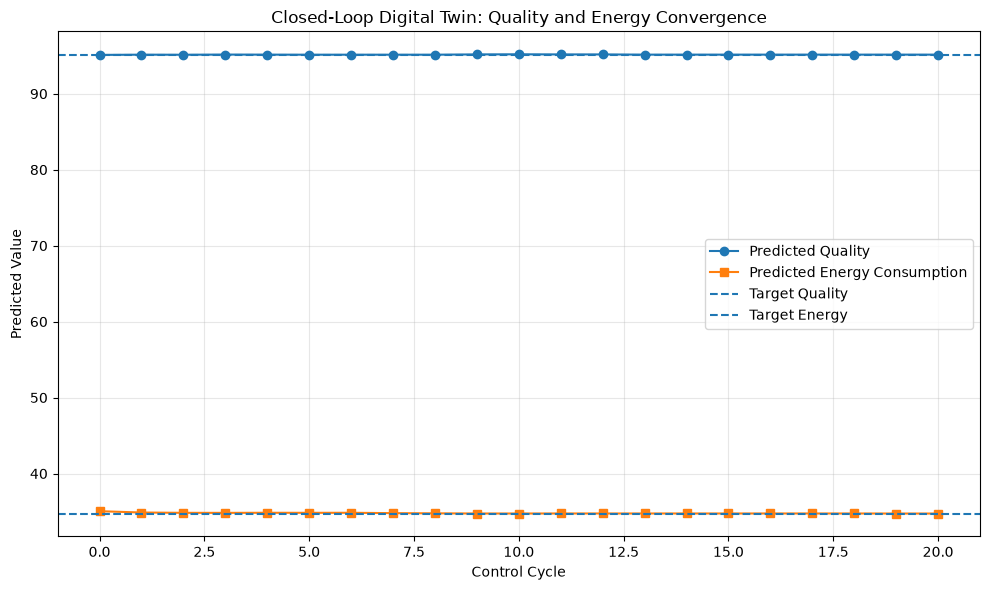

In [19]:
# Step 19: Visualize Closed-Loop Digital Twin Convergence

plt.figure(figsize=(10, 6))

# Plot predicted quality
plt.plot(
    control_history["step"],
    control_history["predicted_quality"],
    marker="o",
    label="Predicted Quality"
)

# Plot predicted energy consumption
plt.plot(
    control_history["step"],
    control_history["predicted_energy"],
    marker="s",
    label="Predicted Energy Consumption"
)

# Reference lines for optimized target
plt.axhline(
    y=best_balanced["predicted_quality"],
    linestyle="--",
    label="Target Quality"
)

plt.axhline(
    y=best_balanced["predicted_energy"],
    linestyle="--",
    label="Target Energy"
)

plt.xlabel("Control Cycle")
plt.ylabel("Predicted Value")

plt.title(
    "Closed-Loop Digital Twin: "
    "Quality and Energy Convergence"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

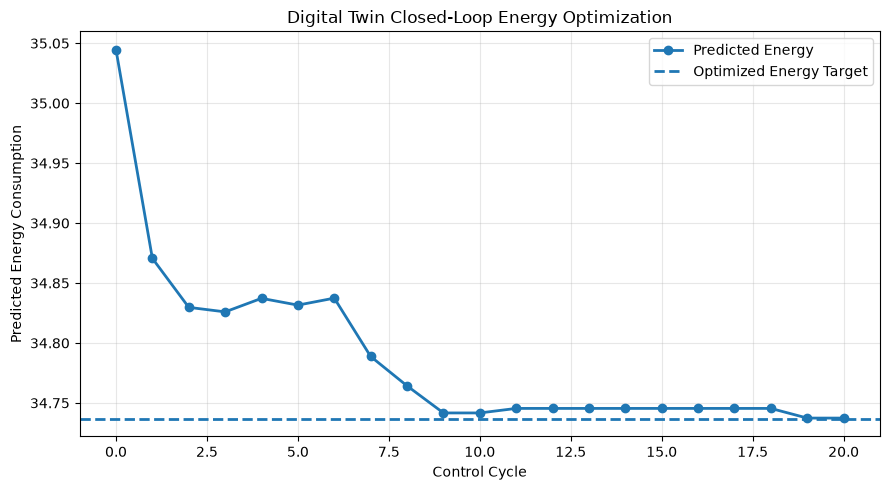

In [20]:
# Step 20: Detailed Energy Convergence

plt.figure(figsize=(9, 5))

plt.plot(
    control_history["step"],
    control_history["predicted_energy"],
    marker="o",
    linewidth=2,
    label="Predicted Energy"
)

plt.axhline(
    y=best_balanced["predicted_energy"],
    linestyle="--",
    linewidth=2,
    label="Optimized Energy Target"
)

plt.xlabel("Control Cycle")
plt.ylabel("Predicted Energy Consumption")
plt.title("Digital Twin Closed-Loop Energy Optimization")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

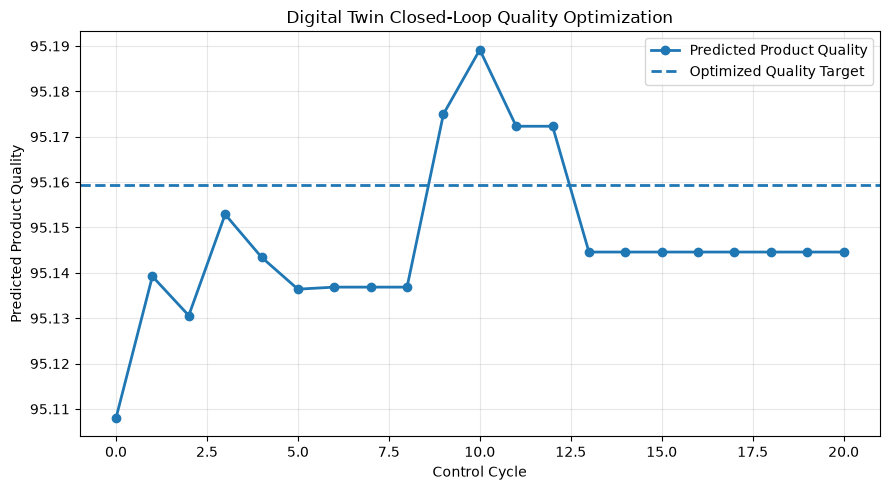

In [21]:
# Step 21: Detailed Product Quality Convergence

plt.figure(figsize=(9, 5))

plt.plot(
    control_history["step"],
    control_history["predicted_quality"],
    marker="o",
    linewidth=2,
    label="Predicted Product Quality"
)

plt.axhline(
    y=best_balanced["predicted_quality"],
    linestyle="--",
    linewidth=2,
    label="Optimized Quality Target"
)

plt.xlabel("Control Cycle")
plt.ylabel("Predicted Product Quality")

plt.title(
    "Digital Twin Closed-Loop Quality Optimization"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

In [22]:
# Step 22: Final KPI summary of the Digital Twin optimization

# Initial operating condition
initial_quality = control_history.iloc[0]["predicted_quality"]
initial_energy = control_history.iloc[0]["predicted_energy"]

# Final closed-loop operating condition
final_quality = control_history.iloc[-1]["predicted_quality"]
final_energy = control_history.iloc[-1]["predicted_energy"]

# Calculate KPI improvements
quality_change = final_quality - initial_quality
energy_reduction = initial_energy - final_energy
energy_reduction_percent = (energy_reduction / initial_energy) * 100

# Distance from optimized target
quality_target_error = abs(
    final_quality - best_balanced["predicted_quality"]
)

energy_target_error = abs(
    final_energy - best_balanced["predicted_energy"]
)

# Create KPI summary table
kpi_summary = pd.DataFrame({
    "KPI": [
        "Product Quality",
        "Energy Consumption",
        "Quality Change",
        "Energy Reduction",
        "Energy Reduction (%)",
        "Quality Target Error",
        "Energy Target Error"
    ],
    "Value": [
        final_quality,
        final_energy,
        quality_change,
        energy_reduction,
        energy_reduction_percent,
        quality_target_error,
        energy_target_error
    ]
})

print("=== Digital Twin Final KPI Summary ===")
print()
print(f"Initial Quality: {initial_quality:.3f}")
print(f"Final Quality:   {final_quality:.3f}")
print()

print(f"Initial Energy Consumption: {initial_energy:.3f}")
print(f"Final Energy Consumption:   {final_energy:.3f}")
print()

print(f"Quality Change: {quality_change:+.3f} points")
print(f"Energy Reduction: {energy_reduction:.3f} units")
print(f"Energy Reduction Percentage: {energy_reduction_percent:.2f}%")

print()
print("=== Target Tracking Performance ===")
print(f"Quality Target Error: {quality_target_error:.4f}")
print(f"Energy Target Error: {energy_target_error:.4f}")

kpi_summary

=== Digital Twin Final KPI Summary ===

Initial Quality: 95.108
Final Quality:   95.145

Initial Energy Consumption: 35.045
Final Energy Consumption:   34.737

Quality Change: +0.037 points
Energy Reduction: 0.307 units
Energy Reduction Percentage: 0.88%

=== Target Tracking Performance ===
Quality Target Error: 0.0149
Energy Target Error: 0.0010


,KPI,Value
0,Product Quality,95.144587
1,Energy Consumption,34.737353
2,Quality Change,0.036598
3,Energy Reduction,0.307203
4,Energy Reduction (%),0.876606
5,Quality Target Error,0.014886
6,Energy Target Error,0.000975


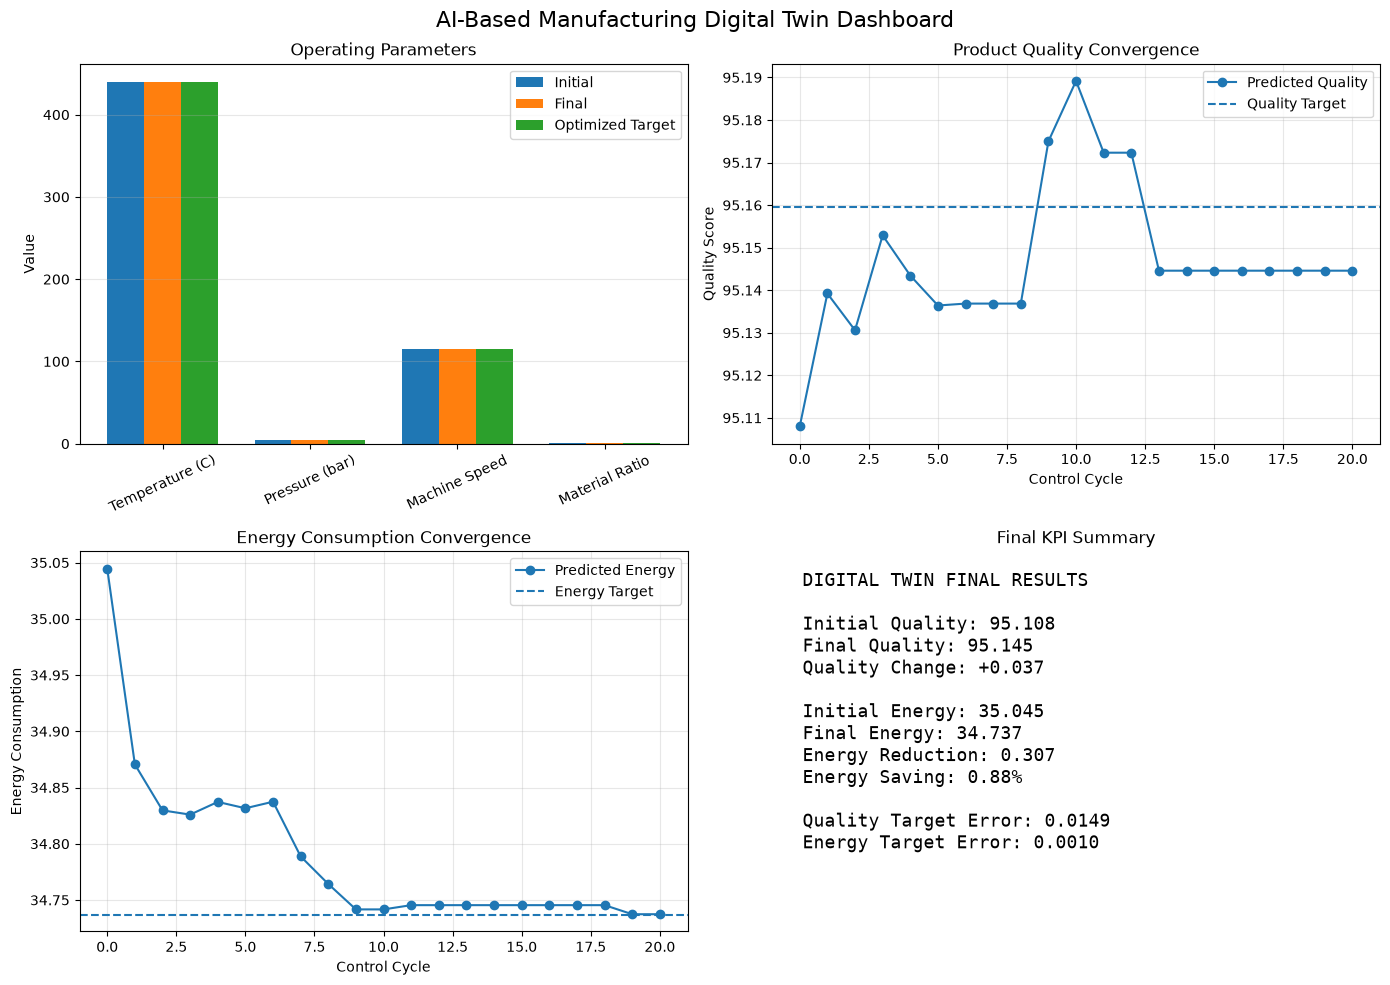

In [23]:
# Step 23: Final Digital Twin Performance Dashboard

# Prepare values
initial_state = control_history.iloc[0]
final_state = control_history.iloc[-1]

labels = [
    "Temperature (C)",
    "Pressure (bar)",
    "Machine Speed",
    "Material Ratio"
]

initial_values = [
    initial_state["temperature_C"],
    initial_state["pressure_bar"],
    initial_state["machine_speed"],
    initial_state["material_ratio"]
]

final_values = [
    final_state["temperature_C"],
    final_state["pressure_bar"],
    final_state["machine_speed"],
    final_state["material_ratio"]
]

target_values = [
    best_balanced["temperature_C"],
    best_balanced["pressure_bar"],
    best_balanced["machine_speed"],
    best_balanced["material_ratio"]
]

# Create dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---------------------------------
# 1. Operating parameters
# ---------------------------------
x = np.arange(len(labels))
width = 0.25

axes[0, 0].bar(
    x - width, initial_values,
    width, label="Initial"
)

axes[0, 0].bar(
    x, final_values,
    width, label="Final"
)

axes[0, 0].bar(
    x + width, target_values,
    width, label="Optimized Target"
)

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(labels, rotation=25)
axes[0, 0].set_title("Operating Parameters")
axes[0, 0].set_ylabel("Value")
axes[0, 0].legend()
axes[0, 0].grid(axis="y", alpha=0.3)

# ---------------------------------
# 2. Quality convergence
# ---------------------------------
axes[0, 1].plot(
    control_history["step"],
    control_history["predicted_quality"],
    marker="o",
    label="Predicted Quality"
)

axes[0, 1].axhline(
    best_balanced["predicted_quality"],
    linestyle="--",
    label="Quality Target"
)

axes[0, 1].set_title("Product Quality Convergence")
axes[0, 1].set_xlabel("Control Cycle")
axes[0, 1].set_ylabel("Quality Score")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ---------------------------------
# 3. Energy convergence
# ---------------------------------
axes[1, 0].plot(
    control_history["step"],
    control_history["predicted_energy"],
    marker="o",
    label="Predicted Energy"
)

axes[1, 0].axhline(
    best_balanced["predicted_energy"],
    linestyle="--",
    label="Energy Target"
)

axes[1, 0].set_title("Energy Consumption Convergence")
axes[1, 0].set_xlabel("Control Cycle")
axes[1, 0].set_ylabel("Energy Consumption")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# ---------------------------------
# 4. Final KPI summary
# ---------------------------------
axes[1, 1].axis("off")

summary_text = (
    "DIGITAL TWIN FINAL RESULTS\n\n"
    f"Initial Quality: {initial_quality:.3f}\n"
    f"Final Quality: {final_quality:.3f}\n"
    f"Quality Change: {quality_change:+.3f}\n\n"
    f"Initial Energy: {initial_energy:.3f}\n"
    f"Final Energy: {final_energy:.3f}\n"
    f"Energy Reduction: {energy_reduction:.3f}\n"
    f"Energy Saving: {energy_reduction_percent:.2f}%\n\n"
    f"Quality Target Error: {quality_target_error:.4f}\n"
    f"Energy Target Error: {energy_target_error:.4f}"
)

axes[1, 1].text(
    0.05,
    0.95,
    summary_text,
    transform=axes[1, 1].transAxes,
    fontsize=13,
    verticalalignment="top",
    family="monospace"
)

axes[1, 1].set_title("Final KPI Summary")

plt.suptitle(
    "AI-Based Manufacturing Digital Twin Dashboard",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [24]:
# Step 24: Simulate a manufacturing process disturbance

# Normal operating condition
normal_state = pd.DataFrame({
    "temperature_C": [440.0],
    "pressure_bar": [4.25],
    "machine_speed": [115.0],
    "material_ratio": [0.320]
})

# Introduce a process disturbance / fault
disturbed_state = normal_state.copy()

# Simulated sensor/process disturbances
disturbed_state.loc[0, "temperature_C"] += 35.0
disturbed_state.loc[0, "pressure_bar"] -= 0.45
disturbed_state.loc[0, "machine_speed"] += 12.0

# Digital Twin predictions before disturbance
normal_quality = quality_model.predict(
    normal_state[features]
)[0]

normal_energy = energy_model.predict(
    normal_state[features]
)[0]

# Digital Twin predictions after disturbance
disturbed_quality = quality_model.predict(
    disturbed_state[features]
)[0]

disturbed_energy = energy_model.predict(
    disturbed_state[features]
)[0]

# Calculate impact of disturbance
quality_impact = disturbed_quality - normal_quality
energy_impact = disturbed_energy - normal_energy

print("=== Digital Twin Disturbance Simulation ===")

print("\nNormal operating condition:")
print(normal_state)

print("\nDisturbed operating condition:")
print(disturbed_state)

print("\n=== Digital Twin Predictions ===")

print(f"Normal Quality:     {normal_quality:.3f}")
print(f"Disturbed Quality:  {disturbed_quality:.3f}")
print(f"Quality Change:     {quality_impact:+.3f}")

print()

print(f"Normal Energy:      {normal_energy:.3f}")
print(f"Disturbed Energy:   {disturbed_energy:.3f}")
print(f"Energy Change:      {energy_impact:+.3f}")

# Fault detection logic
quality_threshold = 0.5
energy_threshold = 0.5

quality_fault = abs(quality_impact) > quality_threshold
energy_fault = abs(energy_impact) > energy_threshold

print("\n=== Fault Detection ===")

if quality_fault:
    print("WARNING: Significant quality deviation detected.")
else:
    print("Quality deviation is within acceptable limits.")

if energy_fault:
    print("WARNING: Significant energy deviation detected.")
else:
    print("Energy deviation is within acceptable limits.")

if quality_fault or energy_fault:
    print("\nDIGITAL TWIN STATUS: DISTURBANCE DETECTED")
else:
    print("\nDIGITAL TWIN STATUS: NORMAL")

=== Digital Twin Disturbance Simulation ===

Normal operating condition:
   temperature_C  pressure_bar  machine_speed  material_ratio
0          440.0          4.25          115.0            0.32

Disturbed operating condition:
   temperature_C  pressure_bar  machine_speed  material_ratio
0          475.0           3.8          127.0            0.32

=== Digital Twin Predictions ===
Normal Quality:     95.108
Disturbed Quality:  91.236
Quality Change:     -3.872

Normal Energy:      35.045
Disturbed Energy:   35.651
Energy Change:      +0.606

=== Fault Detection ===

DIGITAL TWIN STATUS: DISTURBANCE DETECTED


In [25]:
# Step 25: Automatic Digital Twin recovery after disturbance

# Start recovery from the disturbed operating condition
recovery_state = disturbed_state.copy()

# Optimized target obtained previously
recovery_target = pd.Series({
    "temperature_C": best_balanced["temperature_C"],
    "pressure_bar": best_balanced["pressure_bar"],
    "machine_speed": best_balanced["machine_speed"],
    "material_ratio": best_balanced["material_ratio"]
})

# Number of recovery control cycles
n_recovery_steps = 20

# Controller response factor
recovery_rate = 0.25

recovery_history = []

print("=== Digital Twin Automatic Recovery ===")

for step in range(n_recovery_steps + 1):

    # Predict current quality and energy
    current_quality = quality_model.predict(
        recovery_state[features]
    )[0]

    current_energy = energy_model.predict(
        recovery_state[features]
    )[0]

    # Save current state
    recovery_history.append({
        "step": step,
        "temperature_C": recovery_state["temperature_C"].iloc[0],
        "pressure_bar": recovery_state["pressure_bar"].iloc[0],
        "machine_speed": recovery_state["machine_speed"].iloc[0],
        "material_ratio": recovery_state["material_ratio"].iloc[0],
        "predicted_quality": current_quality,
        "predicted_energy": current_energy
    })

    # Move operating parameters toward optimized target
    for feature in features:

        current_value = recovery_state[feature].iloc[0]
        target_value = recovery_target[feature]

        new_value = current_value + recovery_rate * (
            target_value - current_value
        )

        recovery_state.loc[0, feature] = new_value


# Convert recovery history to DataFrame
recovery_history = pd.DataFrame(recovery_history)


# Final recovered condition
final_recovery = recovery_history.iloc[-1]


print("\nDisturbed condition:")
print(f"Temperature: {disturbed_state['temperature_C'].iloc[0]:.3f}")
print(f"Pressure: {disturbed_state['pressure_bar'].iloc[0]:.3f}")
print(f"Machine Speed: {disturbed_state['machine_speed'].iloc[0]:.3f}")
print(f"Material Ratio: {disturbed_state['material_ratio'].iloc[0]:.3f}")

print("\nRecovered condition:")
print(f"Temperature: {final_recovery['temperature_C']:.3f}")
print(f"Pressure: {final_recovery['pressure_bar']:.3f}")
print(f"Machine Speed: {final_recovery['machine_speed']:.3f}")
print(f"Material Ratio: {final_recovery['material_ratio']:.3f}")

print("\n=== Performance Recovery ===")

print(
    f"Quality: {disturbed_quality:.3f} "
    f"-> {final_recovery['predicted_quality']:.3f}"
)

print(
    f"Energy: {disturbed_energy:.3f} "
    f"-> {final_recovery['predicted_energy']:.3f}"
)

print("\nOptimized targets:")

print(
    f"Target Quality: "
    f"{best_balanced['predicted_quality']:.3f}"
)

print(
    f"Target Energy: "
    f"{best_balanced['predicted_energy']:.3f}"
)

recovery_history.tail()

=== Digital Twin Automatic Recovery ===

Disturbed condition:
Temperature: 475.000
Pressure: 3.800
Machine Speed: 127.000
Material Ratio: 0.320

Recovered condition:
Temperature: 439.252
Pressure: 4.226
Machine Speed: 115.397
Material Ratio: 0.318

=== Performance Recovery ===
Quality: 91.236 -> 95.163
Energy: 35.651 -> 34.734

Optimized targets:
Target Quality: 95.159
Target Energy: 34.736


,step,temperature_C,pressure_bar,machine_speed,material_ratio,predicted_quality,predicted_energy
16,16,439.497242,4.223020,115.476368,0.318496,95.131085,34.768337
17,17,439.407384,4.224091,115.447202,0.318493,95.122000,34.776401
18,18,439.339990,4.224894,115.425327,0.318490,95.122452,34.733575
19,19,439.289445,4.225496,115.408920,0.318488,95.122452,34.733575
20,20,439.251536,4.225947,115.396616,0.318486,95.162719,34.733575


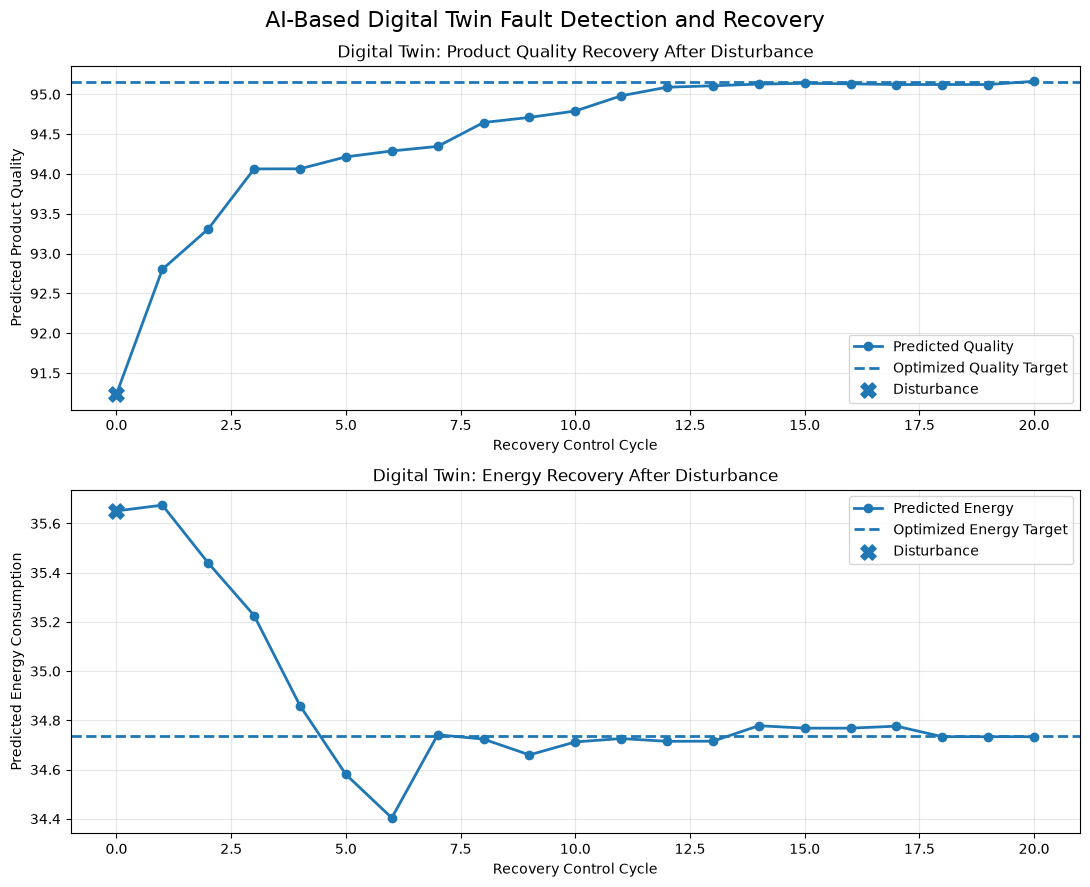

In [26]:
# Step 26: Visualize Digital Twin fault detection and automatic recovery

recovery_steps = recovery_history["step"]

fig, axes = plt.subplots(2, 1, figsize=(11, 9))

# ==========================================
# 1. Product Quality Recovery
# ==========================================

axes[0].plot(
    recovery_steps,
    recovery_history["predicted_quality"],
    marker="o",
    linewidth=2,
    label="Predicted Quality"
)

# Optimized quality target
axes[0].axhline(
    best_balanced["predicted_quality"],
    linestyle="--",
    linewidth=2,
    label="Optimized Quality Target"
)

# Disturbance point
axes[0].scatter(
    0,
    disturbed_quality,
    s=120,
    marker="X",
    label="Disturbance"
)

axes[0].set_title(
    "Digital Twin: Product Quality Recovery After Disturbance"
)

axes[0].set_xlabel("Recovery Control Cycle")
axes[0].set_ylabel("Predicted Product Quality")

axes[0].grid(alpha=0.3)
axes[0].legend()


# ==========================================
# 2. Energy Consumption Recovery
# ==========================================

axes[1].plot(
    recovery_steps,
    recovery_history["predicted_energy"],
    marker="o",
    linewidth=2,
    label="Predicted Energy"
)

# Optimized energy target
axes[1].axhline(
    best_balanced["predicted_energy"],
    linestyle="--",
    linewidth=2,
    label="Optimized Energy Target"
)

# Disturbance point
axes[1].scatter(
    0,
    disturbed_energy,
    s=120,
    marker="X",
    label="Disturbance"
)

axes[1].set_title(
    "Digital Twin: Energy Recovery After Disturbance"
)

axes[1].set_xlabel("Recovery Control Cycle")
axes[1].set_ylabel("Predicted Energy Consumption")

axes[1].grid(alpha=0.3)
axes[1].legend()


plt.suptitle(
    "AI-Based Digital Twin Fault Detection and Recovery",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [27]:
# Step 27: Evaluate fault recovery performance

# ------------------------------------------
# 1. Define recovery tolerances
# ------------------------------------------

quality_tolerance = 0.05
energy_tolerance = 0.05

target_quality = best_balanced["predicted_quality"]
target_energy = best_balanced["predicted_energy"]


# ------------------------------------------
# 2. Calculate errors during recovery
# ------------------------------------------

recovery_history["quality_error"] = abs(
    recovery_history["predicted_quality"] - target_quality
)

recovery_history["energy_error"] = abs(
    recovery_history["predicted_energy"] - target_energy
)


# ------------------------------------------
# 3. Detect successful recovery cycles
# ------------------------------------------

recovery_history["within_target"] = (
    (recovery_history["quality_error"] <= quality_tolerance)
    &
    (recovery_history["energy_error"] <= energy_tolerance)
)


# Find first cycle where BOTH objectives
# reach the acceptable region

successful_cycles = recovery_history[
    recovery_history["within_target"]
]

if len(successful_cycles) > 0:
    first_recovery_cycle = int(
        successful_cycles.iloc[0]["step"]
    )
    recovery_success = True
else:
    first_recovery_cycle = None
    recovery_success = False


# ------------------------------------------
# 4. Calculate recovery KPIs
# ------------------------------------------

final_recovery_quality = recovery_history.iloc[-1][
    "predicted_quality"
]

final_recovery_energy = recovery_history.iloc[-1][
    "predicted_energy"
]


# Quality recovered after disturbance
quality_recovered = (
    final_recovery_quality - disturbed_quality
)

# Percentage of lost quality recovered
quality_loss = normal_quality - disturbed_quality

if abs(quality_loss) > 1e-12:
    quality_recovery_percent = (
        quality_recovered / quality_loss
    ) * 100
else:
    quality_recovery_percent = 100.0


# Energy reduction after disturbance
energy_recovered = (
    disturbed_energy - final_recovery_energy
)

energy_recovery_percent = (
    energy_recovered / disturbed_energy
) * 100


# ------------------------------------------
# 5. Final recovery status
# ------------------------------------------

final_quality_error = abs(
    final_recovery_quality - target_quality
)

final_energy_error = abs(
    final_recovery_energy - target_energy
)

final_success = (
    final_quality_error <= quality_tolerance
    and
    final_energy_error <= energy_tolerance
)


# ------------------------------------------
# 6. Print KPI report
# ------------------------------------------

print("=== Digital Twin Fault-Recovery KPI Report ===")

print("\nDisturbance impact:")
print(
    f"Quality after disturbance: "
    f"{disturbed_quality:.3f}"
)
print(
    f"Energy after disturbance: "
    f"{disturbed_energy:.3f}"
)

print("\nRecovery performance:")
print(
    f"Final recovered quality: "
    f"{final_recovery_quality:.3f}"
)
print(
    f"Final recovered energy: "
    f"{final_recovery_energy:.3f}"
)

print(
    f"Quality recovered: "
    f"{quality_recovered:.3f} points"
)

print(
    f"Quality recovery: "
    f"{quality_recovery_percent:.2f}%"
)

print(
    f"Energy reduction during recovery: "
    f"{energy_recovered:.3f} units"
)

print(
    f"Energy reduction percentage: "
    f"{energy_recovery_percent:.2f}%"
)

print("\nTarget tracking:")
print(
    f"Final quality target error: "
    f"{final_quality_error:.4f}"
)
print(
    f"Final energy target error: "
    f"{final_energy_error:.4f}"
)

if recovery_success:
    print(
        f"\nFirst acceptable recovery cycle: "
        f"{first_recovery_cycle}"
    )
else:
    print(
        "\nSystem did not reach the acceptable "
        "target region."
    )

print("\n=== FINAL RECOVERY STATUS ===")

if final_success:
    print("SUCCESS: Digital Twin recovered from disturbance.")
else:
    print("WARNING: Recovery target was not fully achieved.")

=== Digital Twin Fault-Recovery KPI Report ===

Disturbance impact:
Quality after disturbance: 91.236
Energy after disturbance: 35.651

Recovery performance:
Final recovered quality: 95.163
Final recovered energy: 34.734
Quality recovered: 3.927 points
Quality recovery: 101.41%
Energy reduction during recovery: 0.917 units
Energy reduction percentage: 2.57%

Target tracking:
Final quality target error: 0.0032
Final energy target error: 0.0028

First acceptable recovery cycle: 14

=== FINAL RECOVERY STATUS ===
SUCCESS: Digital Twin recovered from disturbance.


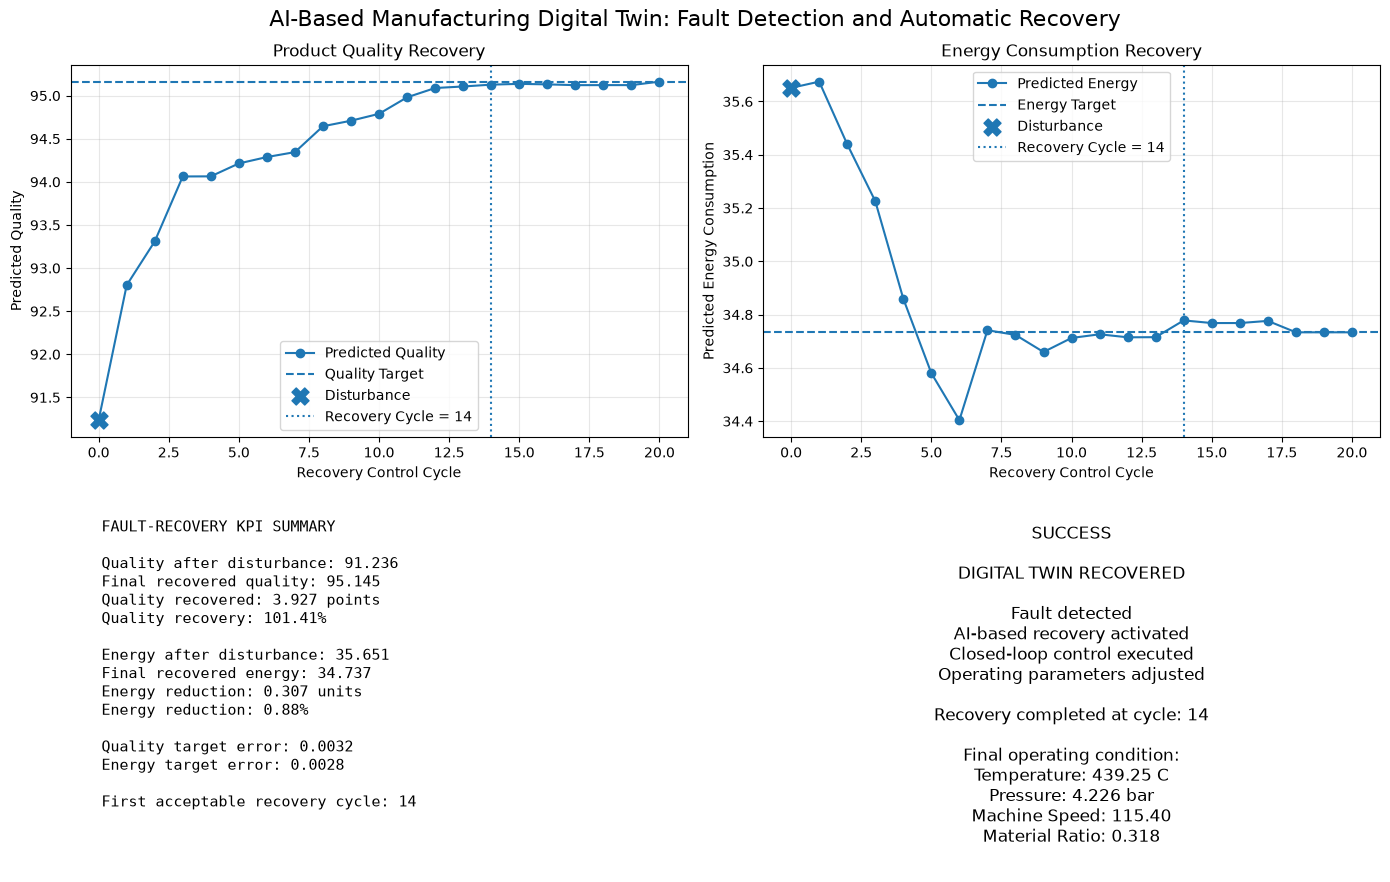

In [28]:
# Step 28: Create final Fault-Recovery Dashboard

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

steps = recovery_history["step"]

# --------------------------------------------------
# 1. Product Quality Recovery
# --------------------------------------------------
axes[0, 0].plot(
    steps,
    recovery_history["predicted_quality"],
    marker="o",
    label="Predicted Quality"
)

axes[0, 0].axhline(
    best_balanced["predicted_quality"],
    linestyle="--",
    label="Quality Target"
)

axes[0, 0].scatter(
    recovery_history["step"].iloc[0],
    recovery_history["predicted_quality"].iloc[0],
    marker="X",
    s=150,
    label="Disturbance"
)

axes[0, 0].axvline(
    first_recovery_cycle,
    linestyle=":",
    label=f"Recovery Cycle = {first_recovery_cycle}"
)

axes[0, 0].set_title("Product Quality Recovery")
axes[0, 0].set_xlabel("Recovery Control Cycle")
axes[0, 0].set_ylabel("Predicted Quality")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()


# --------------------------------------------------
# 2. Energy Consumption Recovery
# --------------------------------------------------
axes[0, 1].plot(
    steps,
    recovery_history["predicted_energy"],
    marker="o",
    label="Predicted Energy"
)

axes[0, 1].axhline(
    best_balanced["predicted_energy"],
    linestyle="--",
    label="Energy Target"
)

axes[0, 1].scatter(
    recovery_history["step"].iloc[0],
    recovery_history["predicted_energy"].iloc[0],
    marker="X",
    s=150,
    label="Disturbance"
)

axes[0, 1].axvline(
    first_recovery_cycle,
    linestyle=":",
    label=f"Recovery Cycle = {first_recovery_cycle}"
)

axes[0, 1].set_title("Energy Consumption Recovery")
axes[0, 1].set_xlabel("Recovery Control Cycle")
axes[0, 1].set_ylabel("Predicted Energy Consumption")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()


# --------------------------------------------------
# 3. Recovery KPI Summary
# --------------------------------------------------
axes[1, 0].axis("off")

kpi_text = (
    "FAULT-RECOVERY KPI SUMMARY\n\n"
    f"Quality after disturbance: {disturbed_quality:.3f}\n"
    f"Final recovered quality: {final_quality:.3f}\n"
    f"Quality recovered: {quality_recovered:.3f} points\n"
    f"Quality recovery: {quality_recovery_percent:.2f}%\n\n"
    f"Energy after disturbance: {disturbed_energy:.3f}\n"
    f"Final recovered energy: {final_energy:.3f}\n"
    f"Energy reduction: {energy_reduction:.3f} units\n"
    f"Energy reduction: {energy_reduction_percent:.2f}%\n\n"
    f"Quality target error: {final_quality_error:.4f}\n"
    f"Energy target error: {final_energy_error:.4f}\n\n"
    f"First acceptable recovery cycle: {first_recovery_cycle}"
)

axes[1, 0].text(
    0.05,
    0.95,
    kpi_text,
    va="top",
    fontsize=11,
    family="monospace"
)


# --------------------------------------------------
# 4. Final Digital Twin Status
# --------------------------------------------------
axes[1, 1].axis("off")

if final_success:
    status = "SUCCESS\n\nDIGITAL TWIN RECOVERED"
else:
    status = "WARNING\n\nRECOVERY TARGET NOT ACHIEVED"

status_text = (
    f"{status}\n\n"
    "Fault detected\n"
    "AI-based recovery activated\n"
    "Closed-loop control executed\n"
    "Operating parameters adjusted\n\n"
    f"Recovery completed at cycle: {first_recovery_cycle}\n\n"
    "Final operating condition:\n"
    f"Temperature: {recovery_history['temperature_C'].iloc[-1]:.2f} C\n"
    f"Pressure: {recovery_history['pressure_bar'].iloc[-1]:.3f} bar\n"
    f"Machine Speed: {recovery_history['machine_speed'].iloc[-1]:.2f}\n"
    f"Material Ratio: {recovery_history['material_ratio'].iloc[-1]:.3f}"
)

axes[1, 1].text(
    0.5,
    0.5,
    status_text,
    ha="center",
    va="center",
    fontsize=12
)

fig.suptitle(
    "AI-Based Manufacturing Digital Twin: Fault Detection and Automatic Recovery",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [29]:
# Step 29: Export final Digital Twin results

import os
import joblib

# Create output directory
output_dir = "../results"
os.makedirs(output_dir, exist_ok=True)


# --------------------------------------------------
# 1. Save optimized manufacturing settings
# --------------------------------------------------

optimized_settings = pd.DataFrame({
    "Parameter": [
        "Temperature (C)",
        "Pressure (bar)",
        "Machine Speed",
        "Material Ratio",
        "Predicted Quality",
        "Predicted Energy Consumption"
    ],
    "Optimized Value": [
        best_balanced["temperature_C"],
        best_balanced["pressure_bar"],
        best_balanced["machine_speed"],
        best_balanced["material_ratio"],
        best_balanced["predicted_quality"],
        best_balanced["predicted_energy"]
    ]
})

optimized_settings.to_csv(
    f"{output_dir}/optimized_manufacturing_settings.csv",
    index=False
)


# --------------------------------------------------
# 2. Save closed-loop control history
# --------------------------------------------------

control_history.to_csv(
    f"{output_dir}/closed_loop_control_history.csv",
    index=False
)


# --------------------------------------------------
# 3. Save fault-recovery history
# --------------------------------------------------

recovery_history.to_csv(
    f"{output_dir}/fault_recovery_history.csv",
    index=False
)


# --------------------------------------------------
# 4. Create final KPI report
# --------------------------------------------------

final_kpi_report = pd.DataFrame({
    "KPI": [
        "Initial Quality",
        "Final Quality",
        "Quality Change",
        "Initial Energy Consumption",
        "Final Energy Consumption",
        "Energy Reduction",
        "Energy Reduction (%)",
        "Quality Target Error",
        "Energy Target Error",
        "Disturbed Quality",
        "Recovered Quality",
        "Quality Recovered",
        "Disturbed Energy",
        "Recovered Energy",
        "Recovery Energy Reduction",
        "First Acceptable Recovery Cycle"
    ],

    "Value": [
        initial_quality,
        final_quality,
        final_quality - initial_quality,
        initial_energy,
        final_energy,
        initial_energy - final_energy,
        ((initial_energy - final_energy) / initial_energy) * 100,
        final_quality_error,
        final_energy_error,
        disturbed_quality,
        recovery_history["predicted_quality"].iloc[-1],
        recovery_history["predicted_quality"].iloc[-1] - disturbed_quality,
        disturbed_energy,
        recovery_history["predicted_energy"].iloc[-1],
        disturbed_energy - recovery_history["predicted_energy"].iloc[-1],
        first_recovery_cycle
    ]
})

final_kpi_report.to_csv(
    f"{output_dir}/digital_twin_final_kpi_report.csv",
    index=False
)


# --------------------------------------------------
# 5. Save trained AI models
# --------------------------------------------------

joblib.dump(
    quality_model,
    f"{output_dir}/quality_prediction_model.pkl"
)

joblib.dump(
    energy_model,
    f"{output_dir}/energy_prediction_model.pkl"
)


# --------------------------------------------------
# Final confirmation
# --------------------------------------------------

print("=== Digital Twin Export Completed ===")

print("\nFiles created:")
print("1. optimized_manufacturing_settings.csv")
print("2. closed_loop_control_history.csv")
print("3. fault_recovery_history.csv")
print("4. digital_twin_final_kpi_report.csv")
print("5. quality_prediction_model.pkl")
print("6. energy_prediction_model.pkl")

print(f"\nOutput directory: {output_dir}")

print("\nFinal KPI Report:")
display(final_kpi_report)

=== Digital Twin Export Completed ===

Files created:
1. optimized_manufacturing_settings.csv
2. closed_loop_control_history.csv
3. fault_recovery_history.csv
4. digital_twin_final_kpi_report.csv
5. quality_prediction_model.pkl
6. energy_prediction_model.pkl

Output directory: ../results

Final KPI Report:


,KPI,Value
0,Initial Quality,95.107988
1,Final Quality,95.144587
2,Quality Change,0.036598
3,Initial Energy Consumption,35.044556
4,Final Energy Consumption,34.737353
5,Energy Reduction,0.307203
6,Energy Reduction (%),0.876606
7,Quality Target Error,0.003247
8,Energy Target Error,0.002803
9,Disturbed Quality,91.235884


In [30]:
# Step 30: Generate Final Digital Twin Executive Summary

print("=" * 70)
print("     AI-BASED MANUFACTURING DIGITAL TWIN - EXECUTIVE SUMMARY")
print("=" * 70)

print("\n[1] DIGITAL TWIN ARCHITECTURE")
print("-" * 45)
print("Physical Process Simulation")
print("        ↓")
print("Manufacturing Data Acquisition")
print("        ↓")
print("AI Prediction Models")
print("        ↓")
print("Quality-Energy Optimization")
print("        ↓")
print("Decision Support")
print("        ↓")
print("Closed-Loop Control")
print("        ↓")
print("Fault Detection & Automatic Recovery")


# --------------------------------------------------
# AI MODEL PERFORMANCE
# --------------------------------------------------

print("\n[2] AI MODEL PERFORMANCE")
print("-" * 45)

print(f"Quality Prediction Model:")
print(f"  MAE : {mae:.3f}")
print(f"  R²  : {r2:.3f}")

print("\nEnergy Prediction Model:")
print(f"  MAE : {energy_mae:.3f}")
print(f"  R²  : {energy_r2:.3f}")


# --------------------------------------------------
# OPTIMIZED OPERATING POINT
# --------------------------------------------------

print("\n[3] OPTIMIZED MANUFACTURING SETTINGS")
print("-" * 45)

print(
    f"Temperature      : "
    f"{best_balanced['temperature_C']:.3f} °C"
)

print(
    f"Pressure         : "
    f"{best_balanced['pressure_bar']:.3f} bar"
)

print(
    f"Machine Speed    : "
    f"{best_balanced['machine_speed']:.3f}"
)

print(
    f"Material Ratio   : "
    f"{best_balanced['material_ratio']:.3f}"
)

print(
    f"Predicted Quality: "
    f"{best_balanced['predicted_quality']:.3f}"
)

print(
    f"Predicted Energy : "
    f"{best_balanced['predicted_energy']:.3f}"
)


# --------------------------------------------------
# CLOSED-LOOP PERFORMANCE
# --------------------------------------------------

print("\n[4] CLOSED-LOOP CONTROL PERFORMANCE")
print("-" * 45)

print(f"Initial Quality : {initial_quality:.3f}")
print(f"Final Quality   : {final_quality:.3f}")

print(
    f"Quality Change  : "
    f"{final_quality - initial_quality:+.3f} points"
)

print()

print(f"Initial Energy  : {initial_energy:.3f}")
print(f"Final Energy    : {final_energy:.3f}")

closed_loop_energy_reduction = initial_energy - final_energy

closed_loop_energy_percent = (
    closed_loop_energy_reduction / initial_energy
) * 100

print(
    f"Energy Reduction: "
    f"{closed_loop_energy_reduction:.3f} units"
)

print(
    f"Energy Saving   : "
    f"{closed_loop_energy_percent:.2f}%"
)


# --------------------------------------------------
# FAULT DETECTION AND RECOVERY
# --------------------------------------------------

print("\n[5] FAULT DETECTION & AUTOMATIC RECOVERY")
print("-" * 45)

recovered_quality = recovery_history["predicted_quality"].iloc[-1]
recovered_energy = recovery_history["predicted_energy"].iloc[-1]

recovery_quality_gain = recovered_quality - disturbed_quality
recovery_energy_reduction = disturbed_energy - recovered_energy

print(f"Quality after disturbance : {disturbed_quality:.3f}")
print(f"Recovered quality         : {recovered_quality:.3f}")

print(
    f"Quality recovered         : "
    f"{recovery_quality_gain:.3f} points"
)

print()

print(f"Energy after disturbance  : {disturbed_energy:.3f}")
print(f"Recovered energy          : {recovered_energy:.3f}")

print(
    f"Recovery energy reduction : "
    f"{recovery_energy_reduction:.3f} units"
)

print(
    f"First acceptable cycle    : "
    f"{first_recovery_cycle}"
)


# --------------------------------------------------
# TARGET TRACKING
# --------------------------------------------------

print("\n[6] TARGET TRACKING ACCURACY")
print("-" * 45)

print(
    f"Final Quality Target Error: "
    f"{final_quality_error:.4f}"
)

print(
    f"Final Energy Target Error : "
    f"{final_energy_error:.4f}"
)


# --------------------------------------------------
# SYSTEM CAPABILITIES
# --------------------------------------------------

print("\n[7] DIGITAL TWIN CAPABILITIES")
print("-" * 45)

capabilities = [
    "Manufacturing process simulation",
    "AI-based product quality prediction",
    "AI-based energy consumption prediction",
    "Multi-objective quality-energy optimization",
    "Optimized operating-point recommendation",
    "Real-time operating-condition evaluation",
    "Closed-loop process control",
    "Manufacturing fault detection",
    "Automatic disturbance recovery",
    "KPI monitoring and visualization",
    "Model and result export"
]

for capability in capabilities:
    print(f"✓ {capability}")


# --------------------------------------------------
# FINAL STATUS
# --------------------------------------------------

print("\n" + "=" * 70)

if final_success:
    print("FINAL SYSTEM STATUS: SUCCESS")
    print(
        "The Digital Twin successfully detected the disturbance, "
        "executed closed-loop recovery, and returned the "
        "manufacturing process to the optimized operating region."
    )
else:
    print("FINAL SYSTEM STATUS: WARNING")
    print(
        "The Digital Twin pipeline executed successfully, "
        "but the final recovery target was not fully achieved."
    )

print("=" * 70)

     AI-BASED MANUFACTURING DIGITAL TWIN - EXECUTIVE SUMMARY

[1] DIGITAL TWIN ARCHITECTURE
---------------------------------------------
Physical Process Simulation
        ↓
Manufacturing Data Acquisition
        ↓
AI Prediction Models
        ↓
Quality-Energy Optimization
        ↓
Decision Support
        ↓
Closed-Loop Control
        ↓
Fault Detection & Automatic Recovery

[2] AI MODEL PERFORMANCE
---------------------------------------------
Quality Prediction Model:
  MAE : 0.889
  R²  : 0.689

Energy Prediction Model:
  MAE : 1.293
  R²  : 0.652

[3] OPTIMIZED MANUFACTURING SETTINGS
---------------------------------------------
Temperature      : 439.138 °C
Pressure         : 4.227 bar
Machine Speed    : 115.360
Material Ratio   : 0.318
Predicted Quality: 95.159
Predicted Energy : 34.736

[4] CLOSED-LOOP CONTROL PERFORMANCE
---------------------------------------------
Initial Quality : 95.108
Final Quality   : 95.145
Quality Change  : +0.037 points

Initial Energy  : 35.045
Fi

In [31]:
# Step 31A: Create requirements.txt

requirements = """numpy
pandas
matplotlib
scikit-learn
joblib
jupyter
"""

with open("../requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [33]:
# Step 31B - Create README.md (fixed version)

readme = '''# AI-Based Manufacturing Digital Twin

An AI-based Digital Twin for manufacturing process monitoring,
quality prediction, energy optimization, closed-loop control,
fault detection, and automatic recovery.

## Project Overview

This project implements an AI-based manufacturing Digital Twin
using machine learning and data-driven process simulation.

## Main Capabilities

- Manufacturing process simulation
- AI-based product quality prediction
- AI-based energy consumption prediction
- Feature importance analysis
- Multi-objective quality-energy optimization
- Optimized operating-point recommendation
- Real-time process monitoring
- Closed-loop process control
- Manufacturing fault detection
- Automatic disturbance recovery
- KPI monitoring and visualization
- AI model and result export

## Machine Learning Models

Two Random Forest regression models are used:

1. Product Quality Prediction Model
2. Energy Consumption Prediction Model

### Input Parameters

- Temperature
- Pressure
- Machine Speed
- Material Ratio

## Model Performance

### Product Quality Model

- MAE: approximately 0.889
- R2 Score: approximately 0.689

### Energy Consumption Model

- MAE: approximately 1.293
- R2 Score: approximately 0.652

## Optimized Manufacturing Settings

- Temperature: approximately 439.138 C
- Pressure: approximately 4.227 bar
- Machine Speed: approximately 115.360
- Material Ratio: approximately 0.318
- Predicted Quality: approximately 95.159
- Predicted Energy Consumption: approximately 34.736

## Closed-Loop Control

The Digital Twin uses AI predictions and optimized targets
to automatically adjust manufacturing operating parameters.

Final closed-loop results:

- Initial Quality: 95.108
- Final Quality: 95.145
- Quality Improvement: approximately 0.037 points
- Initial Energy Consumption: 35.045
- Final Energy Consumption: 34.737
- Energy Reduction: approximately 0.307 units
- Energy Saving: approximately 0.88 percent

## Fault Detection and Automatic Recovery

A simulated manufacturing disturbance was introduced to
evaluate the fault-management capability of the Digital Twin.

After disturbance:

- Product Quality: approximately 91.236
- Energy Consumption: approximately 35.651

After automatic recovery:

- Product Quality: approximately 95.163
- Energy Consumption: approximately 34.734
- Quality Recovered: approximately 3.927 points
- Recovery Energy Reduction: approximately 0.917 units

The system reached the acceptable recovery region at
control cycle 14.

## Final System Status

SUCCESS

The Digital Twin successfully:

1. Detected the manufacturing disturbance
2. Evaluated its impact using AI models
3. Generated corrective operating parameters
4. Executed closed-loop recovery
5. Returned the manufacturing process to the optimized region

## Project Structure

digital-twin-manufacturing/

    notebooks/
        01_digital_twin_manufacturing.ipynb

    data/
        manufacturing_process_data.csv

    results/
        optimized_manufacturing_settings.csv
        closed_loop_control_history.csv
        fault_recovery_history.csv
        digital_twin_final_kpi_report.csv
        quality_prediction_model.pkl
        energy_prediction_model.pkl

    README.md
    requirements.txt

## Technologies

- Python
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- Random Forest Regression
- Jupyter Notebook
- Joblib

## Applications

- Smart Manufacturing
- Industry 4.0
- AI-Based Manufacturing
- Intelligent Process Control
- Energy-Efficient Manufacturing
- Fault Detection and Recovery
- Industrial Decision Support Systems

## Disclaimer

The manufacturing dataset and disturbances used in this project
are synthetic and are intended for simulation, education,
and proof-of-concept development.
'''

with open("../README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [34]:
# Step 31C - Verify final project files

import os

project_files = {
    "Notebook": "../notebooks/01_digital_twin_manufacturing.ipynb",
    "Dataset": "../data/manufacturing_process_data.csv",
    "README": "../README.md",
    "Requirements": "../requirements.txt",
    "Optimized Settings": "../results/optimized_manufacturing_settings.csv",
    "Closed-Loop History": "../results/closed_loop_control_history.csv",
    "Fault Recovery History": "../results/fault_recovery_history.csv",
    "Final KPI Report": "../results/digital_twin_final_kpi_report.csv",
    "Quality Model": "../results/quality_prediction_model.pkl",
    "Energy Model": "../results/energy_prediction_model.pkl"
}

print("=== FINAL PROJECT FILE VERIFICATION ===\n")

all_files_exist = True

for name, path in project_files.items():
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"[OK]      {name:<25} {size_kb:.2f} KB")
    else:
        print(f"[MISSING] {name:<25} {path}")
        all_files_exist = False

print("\n======================================")

if all_files_exist:
    print("SUCCESS: All Digital Twin project files are ready.")
else:
    print("WARNING: Some project files are missing.")

=== FINAL PROJECT FILE VERIFICATION ===

[MISSING] Notebook                  ../notebooks/01_digital_twin_manufacturing.ipynb
[OK]      Dataset                   108.79 KB
[OK]      README                    3.81 KB
[OK]      Requirements              0.06 KB
[OK]      Optimized Settings        0.24 KB
[OK]      Closed-Loop History       2.39 KB
[OK]      Fault Recovery History    3.37 KB
[OK]      Final KPI Report          0.62 KB
[OK]      Quality Model             14290.25 KB
[OK]      Energy Model              14290.25 KB



In [35]:
# Step 31D - Check current working directory

import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
for file in os.listdir("."):
    print(file)

Current working directory:
C:\Users\pycod\OneDrive\Desktop\mini-digital-twin-manufacturing\notebooks

Files in current directory:
.ipynb_checkpoints
01_digital_twin_manufacturing.ipynb.ipynb


In [36]:
# Step 31E - Final project verification with correct notebook detection

import os
import glob

print("=== FINAL PROJECT FILE VERIFICATION ===\n")

# Automatically find the current notebook file
notebooks = glob.glob("*.ipynb")

if notebooks:
    print(f"[OK]      Notebook                  {notebooks[0]}")
else:
    print("[MISSING] Notebook")
    
project_files = {
    "Dataset": "../data/manufacturing_process_data.csv",
    "README": "../README.md",
    "Requirements": "../requirements.txt",
    "Optimized Settings": "../results/optimized_manufacturing_settings.csv",
    "Closed-Loop History": "../results/closed_loop_control_history.csv",
    "Fault Recovery History": "../results/fault_recovery_history.csv",
    "Final KPI Report": "../results/digital_twin_final_kpi_report.csv",
    "Quality Model": "../results/quality_prediction_model.pkl",
    "Energy Model": "../results/energy_prediction_model.pkl"
}

all_files_exist = bool(notebooks)

for name, path in project_files.items():
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"[OK]      {name:<25} {size_kb:.2f} KB")
    else:
        print(f"[MISSING] {name:<25} {path}")
        all_files_exist = False

print("\n========================================")

if all_files_exist:
    print("SUCCESS: All Digital Twin project files are ready.")
else:
    print("WARNING: Some project files are missing.")

=== FINAL PROJECT FILE VERIFICATION ===

[OK]      Notebook                  01_digital_twin_manufacturing.ipynb.ipynb
[OK]      Dataset                   108.79 KB
[OK]      README                    3.81 KB
[OK]      Requirements              0.06 KB
[OK]      Optimized Settings        0.24 KB
[OK]      Closed-Loop History       2.39 KB
[OK]      Fault Recovery History    3.37 KB
[OK]      Final KPI Report          0.62 KB
[OK]      Quality Model             14290.25 KB
[OK]      Energy Model              14290.25 KB

SUCCESS: All Digital Twin project files are ready.


In [37]:
# Step 32 - Create .gitignore for GitHub

gitignore_content = """# Jupyter
.ipynb_checkpoints/

# Python
__pycache__/
*.py[cod]
*.pyo

# Virtual environments
venv/
env/
.venv/

# IDE / Editor
.vscode/
.idea/

# OS files
.DS_Store
Thumbs.db

# Temporary files
*.tmp
*.log
"""

with open("../.gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore_content)

print(".gitignore created successfully!")

.gitignore created successfully!


In [39]:
# Step 33 - Final GitHub repository structure check

import os

project_root = os.path.abspath("..")

print("=== DIGITAL TWIN PROJECT STRUCTURE ===\n")

for root, dirs, files in os.walk(project_root):
    # Ignore unnecessary folders
    dirs[:] = [
        d for d in dirs
       if d not in [".ipynb_checkpoints", "__pycache__", ".git", ".venv", "venv", "env"]
    ]

    level = root.replace(project_root, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = "    " * (level + 1)

    for file in sorted(files):
        print(f"{subindent}{file}")

print("\n======================================")
print("Repository structure check completed.")

=== DIGITAL TWIN PROJECT STRUCTURE ===

mini-digital-twin-manufacturing/
    .gitignore
    .gitignore.txt
    README.md
    README.md.txt
    requirements.txt
    data/
        manufacturing_process_data.csv
        optimized_manufacturing_settings.csv
    figures/
        quality_energy_optimization.png
    notebooks/
        01_digital_twin_manufacturing.ipynb.ipynb
    results/
        closed_loop_control_history.csv
        digital_twin_final_kpi_report.csv
        energy_prediction_model.pkl
        fault_recovery_history.csv
        optimized_manufacturing_settings.csv
        quality_prediction_model.pkl
    src/

Repository structure check completed.
